## Import libs

In [1]:
from sklearn.model_selection import train_test_split
import seaborn as sns


from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_tradeoff, compute_intersectional_fair_metrics
from falsb4mpa.modeling.sk_vanilla.vanilla_lr import VanillaLogisticRegression

## Preliminaries

In [2]:
batch_size = 64
epochs = 100
learning_rate = 0.0001

In [3]:
cv_seeds = [13]
# cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'adult-mpa-bin-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

97 1 1 1 8


## Result file

In [7]:
header = "model_name", "cv_seed", "clas_acc", "a1_dp", "a1_deqodds", "a1_deqopp", "a1_TN_g0", "a1_FP_g0", "a1_FN_g0", "a1_TP_g0", "a1_TN_g1", "a1_FP_g1", "a1_FN_g1", "a1_TP_g1", "a0_dp", "a0_deqodds", "a0_deqopp", "a0_TN_g0", "a0_FP_g0", "a0_FN_g0", "a0_TP_g0", "a0_TN_g1", "a0_FP_g1", "a0_FN_g1", "a0_TP_g1"

results = []

## Testing

In [8]:
results= []
for cv_seed in cv_seeds:
        x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
                x, y, a1, a2, test_size=0.3, random_state=cv_seed
        )
        y_train = y_train.ravel()
        y_test = y_test.ravel()
        
        model = VanillaLogisticRegression(epochs, learning_rate)
        model.fit(x_train, y_train)
         
        Y_hat = model.predict(x_test)

        clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(y_test, Y_hat)
        
        a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(y_test, a1_test, Y_hat, a1dim)
        a2_dp, a2_deqodds, a2_deqopp, a2_metrics_g0, a2_metrics_g1 = compute_fair_metrics(y_test, a2_test, Y_hat, a2dim)

        wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(y_test, a1_test, a2_test, Y_hat, a1dim, a2dim)
        
        # fair_metrics = (dp, deqodds, deqopp)
        
        # tradeoff = []
        
        # for fair_metric in fair_metrics:
        #         tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
        
        # result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]]

        result = ['SkVanillaLR', cv_seed, clas_acc, a1_dp, a1_deqodds, a1_deqopp] + a1_metrics_g0 + a1_metrics_g1 
        result += [a2_dp, a2_deqodds, a2_deqopp] + a2_metrics_g0 + a2_metrics_g1
        result += [wc_spd, wc_aod, wc_eod]

        results.append(result)
        

> Predictive Performance Evaluation
> Class Acc = 0.8308395147323608
> Confusion Matrix 
TN: 9524.0 | FP: 685.0 
FN: 1610.0 | TP: 1748.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8274666666984558 | 0.8849629163742065 | 0.8467037081718445
> Confusion Matrix for A = 0 
TN: 5713.0 | FP: 609.0 
FN: 1298.0 | TP: 1548.0
> Confusion Matrix for A = 1 
TN: 3811.0 | FP: 76.0 
FN: 312.0 | TP: 200.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.9230625629425049 | 0.970474123954773 | 0.970144510269165
> Confusion Matrix for A = 0 
TN: 7971.0 | FP: 616.0 
FN: 1457.0 | TP: 1599.0
> Confusion Matrix for A = 1 
TN: 1553.0 | FP: 69.0 
FN: 153.0 | TP: 149.0
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.7996587753295898 | 0.8628484010696411 | 0.8088096976280212


/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.8308395 0.8308395371121102 0.7480829943285255


<Axes: >

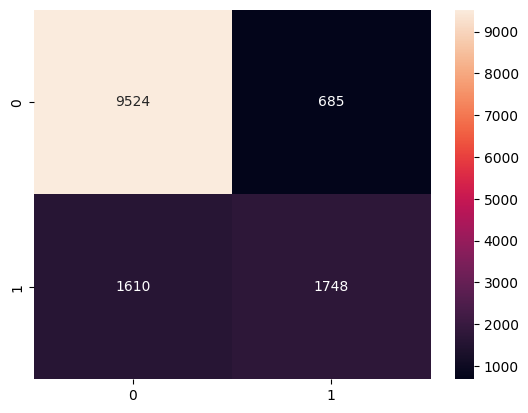

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [11]:
# result_df = pd.DataFrame(results, columns=header)
# result_df

In [12]:
# result_df.to_csv(f'{data_name}-result/unfair_lr-{epochs}.csv')